<a href="https://colab.research.google.com/github/aahan-rd/ECON3916-Statistical-Machine-Learnin/blob/main/lab_ch22_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.ATM.CO2E.PC': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

# Fetch most recent available values
df = wb.data.DataFrame(list(indicators.keys()), mrv=1, labels=True)
df = df.rename(columns=indicators)

# Drop countries with too much missing data, then impute remainder
df = df.dropna(thresh=7)  # Keep countries with at least 7 of 10 indicators
df = df.fillna(df.median())  # Impute remaining NAs with column median

print(f'Countries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

TypeError: Cannot perform reduction 'median' with string dtype

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [9]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

KeyError: "['co2_per_capita'] not in index"

## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [16]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,      # Number of clusters (match World Bank income groups)
    init='k-means++',            # Initialization method (string: 'k-means++')
    n_init='auto',
    random_state=___     # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

InvalidParameterError: The 'random_state' parameter of KMeans must be an int in the range [0, 4294967295], an instance of 'numpy.random.mtrand.RandomState' or None. Got '' instead.

In [13]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

NameError: name 'X_scaled' is not defined

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    income_groups[economy['id']] = economy.get('incomeLevel', {}).get('id', 'Unknown')

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],   # FILL IN: algorithmic cluster column
    df_compare['wb_income'],   # FILL IN: World Bank income group column
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

In [ ]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



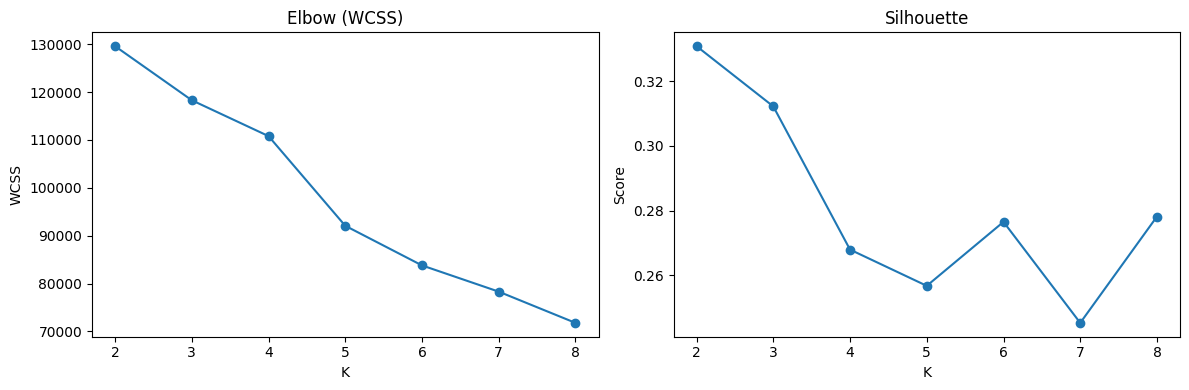

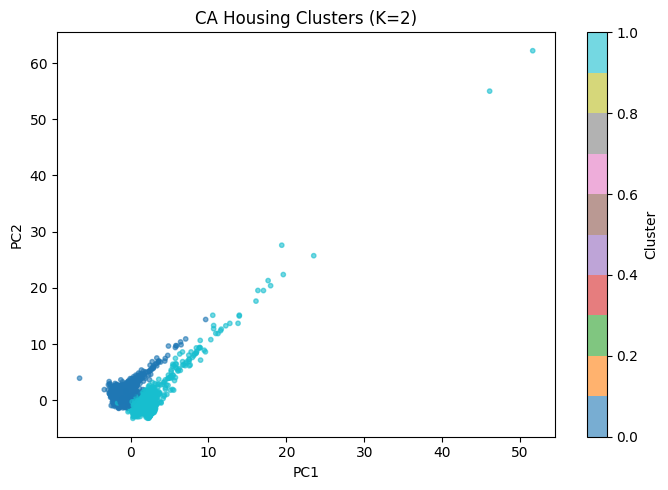

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
cluster,,,,,,,,
0,3.918,28.413,5.225,1.076,1532.242,3.098,33.946,-118.01
1,3.805,28.952,5.710,1.126,1278.280,3.033,37.957,-121.72


In [15]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
# Load + features
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
X = cal_df.drop(columns=["MedHouseVal"])

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# Elbow + silhouette (K=2..8)
K_range = range(2, 9)
wcss = []
sil = []

for k in K_range:
    km = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

best_k = list(K_range)[int(np.argmax(sil))]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_range), wcss, "o-")
ax[0].set(title="Elbow (WCSS)", xlabel="K", ylabel="WCSS")
ax[1].plot(list(K_range), sil, "o-")
ax[1].set(title="Silhouette", xlabel="K", ylabel="Score")
plt.tight_layout()
plt.show()

# Fit final KMeans
kmeans = KMeans(n_clusters=best_k, init="k-means++", n_init="auto", random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# PCA plot
Z = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
plt.figure(figsize=(7, 5))
plt.scatter(Z[:, 0], Z[:, 1], c=clusters, cmap="tab10", s=10, alpha=0.6)
plt.title(f"CA Housing Clusters (K={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()

# Cluster summary (means)
summary = X.assign(cluster=clusters).groupby("cluster").mean(numeric_only=True).round(3)
display(summary)

---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.